Ce fichier test la méthode Coley détaillée dans le rapport mindmaze du 26.07.2024. Le modèle prédit pour 1 sec un "mouvement" ou un "non mouvement", puis ces résultats sont comparés aux annotations disponnibles dans "C:/Users/roman/Documents/BEaCHILD/Classification_RCT2/X_et_Y" (correspondent aux annotations RCT2 de CAP). Les modèles sont évalués par le score d'accuracy et les scores F1 de mouvement et non mouvement.

Les étapes réalisées sont les suivantes:
1. Lecture des fichiers .csv (données des capteurs), récupération des AC et des données de rotation, conversion dans la bonne unité
2. Récuperation des annotations
3. Association des annotations des fichiers excel aux valeurs des fichiers .csv (fait dans 1. et 2.)
4. Application du seuil adaptatif
5. Analyser des résultats (matrices de confusion, accuracy score)
6. Enregistrement dans les fichiers Excel


In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.ndimage import maximum_filter1d
import openpyxl
from agcounts_filter import convert_AC
from sklearn.metrics import accuracy_score, f1_score

In [55]:
idx_premier_fichier = 0#20
idx_dernier_fichier = 4#24

file_path_non_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/Résultats/Coley/Coley_non_dom_04.06.02_MS_02.xlsx"
file_path_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/Résultats/Coley/Coley_dom_04.06.02_MS_02.xlsx"


1. Récupération des accélérations et des annotations

In [56]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/X_et_Y/ZData_231_enlever_juste_pour_RF" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les annotations vidéos
# Annotations all
Y_dom_all = []
Y_non_dom_all = []
# Annotations FAGA
Y_dom_faga = []
Y_non_dom_faga = []
# Annotations GA
Y_dom_ga = []
Y_non_dom_ga = []

#Parcourir les fichiers CSV
for file in folder[idx_premier_fichier:idx_dernier_fichier]:
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None
    allow_start_th = None

    previous_row_dom = 0
    previous_row_non_dom = 0
    previous_row_th = 0

    """******************************************************** 0. Récupération des infos : idx_file / ID / membre dom / non dom *******************************************************"""
    info_file = pd.read_csv(folder_path + "/Info_file.csv", sep = ',')
    file_row = idx_dernier_fichier / 4 - 1

    subject_id = info_file["subject_id"][file_row]
    dom_member = info_file["dom"][file_row]
    non_dom_member = info_file["non_dom"][file_row]

    """******************************************************** 1. Lecture des fichiers csv et récupération des données capteurs ******************************************************************************"""
    if extension == ".csv":

        # Conversion en AC 
        lst_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-6:-4] == non_dom_member:
            print("                                                                non_dom : ", non_dom_member)
            list_non_dom_x = lst_AC["Axis1"].tolist()
            list_non_dom_y = lst_AC["Axis2"].tolist()
            list_non_dom_z = lst_AC["Axis3"].tolist()

        elif file[-6:-4] == dom_member:
            print("                                                                dom : ", dom_member)
            list_dom_x = lst_AC["Axis1"].tolist()
            list_dom_y = lst_AC["Axis2"].tolist()
            list_dom_z = lst_AC["Axis3"].tolist()

        """elif file[-6:-4] == "TH":
            list_th_x = lst_AC["Axis1"].tolist()
            list_th_y = lst_AC["Axis2"].tolist()
            list_th_z = lst_AC["Axis3"].tolist()"""

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de X ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == f"Start_{dom_member}" :
                row_start_dom = label.row
                # Cas ou le capteur dom est allumé en dernier
                if allow_start_non_dom :#and allow_start_th :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) 
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value))
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value))
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == f"Start_{non_dom_member}" :
                row_start_non_dom = label.row
                # Cas ou le capteur non_dom est allumé en dernier
                if allow_start_dom :#and allow_start_th :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) #
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value)) #round
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value))
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True
            
            """# thorax
            if label.value == "Start_Thorax" :
                row_start_th = label.row
                # Cas ou le capteur thorax est allumé en dernier
                if allow_start_dom and allow_start_non_dom :
                    # Récuperer le nb de secondes enregistees avant le start général
                    decalage_start_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_dom , 13).value)) #
                    decalage_start_non_dom = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_non_dom , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_non_dom , 13).value)) #
                    decalage_start_th = round(float(my_sheet.cell(label.row, 13).value)) - round(float(my_sheet.cell(row_start_th , 13).value)) #round(float(my_sheet.cell(label.row, 13).value) - float(my_sheet.cell(row_start_th , 13).value)) #
                    # Mise à jour du start général
                    previous_row_th = label.row
                    previous_row_dom = label.row
                    previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_th = True"""

            """****************************************************** Récupération du contenu de Y ****************************************"""

            # Synchroniser X_dom et X_non_dom avec X_th
            if allow_start_dom and allow_start_non_dom :#and allow_start_th :
                
                # Récupération des labels dom
                if label.value[0:2] == dom_member:

                    # Récupération de l'index de la ligne
                    row = label.row

                    # *******************************************************************  Secondes non annotées **************************************************
                    # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                    if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                        difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 

                        for diff in range(0, difference):
                            Y_dom_ga.append(None)
                            Y_dom_faga.append(None)
                            Y_dom_all.append(None) #//////////////////////////////////////////////////////////// regarder ici : peut etre qu'il ne faut pas mettre de none dans les annotations

                    # *******************************************************************  Secondes annotées **************************************************
                    nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                    for nb_sec in range(nb_repetitions): 
                        # GA
                        if label.value[-5:] == " V GA":
                            Y_dom_ga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                            Y_dom_ga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_ga.append(None)

                        # FAGA
                        if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                            Y_dom_faga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                            Y_dom_faga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_faga.append(None)

                        # all
                        if label.value[-2:] == "GA" or label.value[-2:] == "FA": 
                            Y_dom_all.append("mouvement")
                        elif label.value[3:13] == "sédentaire": 
                            Y_dom_all.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_dom_all.append(None)

                    #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                    previous_row_dom = label.row


                # Récupération des labels non dom
                elif label.value[0:2] == non_dom_member:
                    # Récupération de l'index de la ligne
                    row = label.row

                    # *******************************************************************  Secondes non annotées **************************************************
                    # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                    if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                        difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                        for diff in range(0,difference):
                            Y_non_dom_ga.append(None)
                            Y_non_dom_faga.append(None)
                            Y_non_dom_all.append(None)
                            

                    #  *******************************************************************  Secondes annotées **************************************************
                    nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                    for nb_sec in range(nb_repetitions): 

                        # GA 
                        if label.value[-5:] == " V GA":
                            Y_non_dom_ga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                            Y_non_dom_ga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_ga.append(None)
                        # FAGA
                        if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                            Y_non_dom_faga.append("mouvement")
                        elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                            Y_non_dom_faga.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_faga.append(None)

                        # all    
                        if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                            Y_non_dom_all.append("mouvement")
                        elif label.value[3:13] == "sédentaire": 
                            Y_non_dom_all.append("non mouvement")
                        elif label.value[3:12] == "non noté":
                            Y_non_dom_all.append(None)

                    #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                    previous_row_non_dom = label.row

        # Suppression des données des capteurs enregistrées avant le start général (start de synchronisation)
        for sec_a_supp in range(decalage_start_dom):
            list_dom_x.pop(0)
            list_dom_y.pop(0)
            list_dom_z.pop(0)
        for sec_a_supp in range(decalage_start_non_dom):
            list_non_dom_x.pop(0)
            list_non_dom_y.pop(0)
            list_non_dom_z.pop(0)
        """for sec_a_supp in range(decalage_start_th):
            list_th_x.pop(0)
            list_th_y.pop(0)
            list_th_z.pop(0)"""

        # Découpage de toutes les listes à la même longueur
        min_longueur = min(len(list_dom_x), len(list_non_dom_x), len(Y_dom_all), len(Y_non_dom_all))# len(list_th_x),
        list_dom_x = list_dom_x[:min_longueur]
        list_dom_y = list_dom_y[:min_longueur]
        list_dom_z = list_dom_z[:min_longueur]
        list_non_dom_x = list_non_dom_x[:min_longueur]
        list_non_dom_y = list_non_dom_y[:min_longueur]
        list_non_dom_z = list_non_dom_z[:min_longueur]
        list_th_x = list_th_x[:min_longueur]
        list_th_y = list_th_y[:min_longueur]
        list_th_z = list_th_z[:min_longueur]
        Y_dom_all = Y_dom_all[:min_longueur]
        Y_non_dom_all = Y_non_dom_all[:min_longueur]
        Y_dom_faga = Y_dom_faga[:min_longueur]
        Y_non_dom_faga = Y_non_dom_faga[:min_longueur]
        Y_dom_ga = Y_dom_ga[:min_longueur]
        Y_non_dom_ga = Y_non_dom_ga[:min_longueur]
    

Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
list_dom_x = np.array(list_dom_x)
list_dom_y = np.array(list_dom_y)
list_dom_z = np.array(list_dom_z)
list_non_dom_x = np.array(list_non_dom_x)
list_non_dom_y = np.array(list_non_dom_y)
list_non_dom_z = np.array(list_non_dom_z)

On est dans le fichier : Data_231_LW.csv
Reading in CSV
Converting to array
Getting Counts
                                                                dom :  LW
On est dans le fichier : Data_231_RW.csv
Reading in CSV
Converting to array
Getting Counts
                                                                non_dom :  RW
On est dans le fichier : Data_231_TH.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_231_X.xlsx


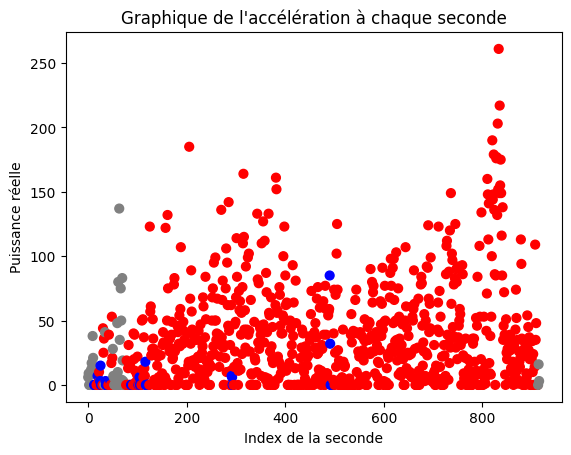

In [57]:

# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_dom_all]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(list_dom_z)), list_dom_z, c=colors, s=40)
plt.title("Graphique de l'accélération à chaque seconde")
plt.xlabel("Index de la seconde")
plt.ylabel("Puissance réelle")
plt.show()


2. Récupération des données gyroscopiques

In [58]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification_RCT2/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_gyro_dom_128_Hz = []
Y_gyro_dom_128_Hz = []
Z_gyro_dom_128_Hz = []
X_gyro_non_dom_128_Hz = []
Y_gyro_non_dom_128_Hz = []
Z_gyro_non_dom_128_Hz = []

X_gyro_dom = []
Y_gyro_dom = []
Z_gyro_dom = []
X_gyro_non_dom = []
Y_gyro_non_dom = []
Z_gyro_non_dom = []


for file in folder[idx_premier_fichier:idx_dernier_fichier]:
    print(f"On est dans le fichier : {file}")

    """******************************************************** 1. Récupération des données gyroscopiques *******************************************************"""
    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"]:
            data_file = pd.read_csv(folder_path + '/' + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"], dtype = {"Event":str},low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)
        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 11"]:
            data_file = pd.read_csv(folder_path + '/' + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 11"], dtype = {"Event":str},low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Pressure', 'Temperature', 'Event','Quat W', 'Quat X', 'Quat Y', 'Quat Z',"Unnamed: 14"]: 
            data_file = pd.read_csv(folder_path + '/' + file, skiprows=7,decimal=",", names = ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Pressure', 'Temperature', 'Event','Quat W', 'Quat X', 'Quat Y', 'Quat Z',"Unnamed: 14"],low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)

        print("Dom member : ", dom_member)
        if file[-6:-4] == non_dom_member:
            X_gyro_non_dom_128_Hz.extend(data_file["Gyro X"].astype(float).values.tolist()) 
            Y_gyro_non_dom_128_Hz.extend(data_file["Gyro Y"].astype(float).values.tolist()) 
            Z_gyro_non_dom_128_Hz.extend(data_file["Gyro Z"].astype(float).values.tolist())
        
        elif file[-6:-4] == dom_member:
            X_gyro_dom_128_Hz.extend(data_file["Gyro X"].astype(float).values.tolist()) 
            Y_gyro_dom_128_Hz.extend(data_file["Gyro Y"].astype(float).values.tolist()) 
            Z_gyro_dom_128_Hz.extend(data_file["Gyro Z"].astype(float).values.tolist())

"""
for freq in range(0,len(X_gyro_dom_128_Hz),128):
    X_gyro_dom.append(np.mean(X_gyro_dom_128_Hz[freq:freq+128]))
    Y_gyro_dom.append(np.mean(Y_gyro_dom_128_Hz[freq:freq+128]))
    Z_gyro_dom.append(np.mean(Z_gyro_dom_128_Hz[freq:freq+128]))

for freq in range(0,len(X_gyro_non_dom_128_Hz),128):
    X_gyro_non_dom.append(np.mean(X_gyro_non_dom_128_Hz[freq:freq+128]))
    Y_gyro_non_dom.append(np.mean(Y_gyro_non_dom_128_Hz[freq:freq+128]))
    Z_gyro_non_dom.append(np.mean(Z_gyro_non_dom_128_Hz[freq:freq+128]))"""


# Suppression des données des capteurs enregistrées avant le start général (start de synchronisation)
for sec_a_supp in range(decalage_start_non_dom*128):
    X_gyro_non_dom_128_Hz.pop(0)
    Y_gyro_non_dom_128_Hz.pop(0)
    Z_gyro_non_dom_128_Hz.pop(0)

for sec_a_supp in range(decalage_start_dom*128):
    X_gyro_dom_128_Hz.pop(0)
    Y_gyro_dom_128_Hz.pop(0)
    Z_gyro_dom_128_Hz.pop(0)

print("décalage :", decalage_start_dom)


X_gyro_dom = np.array(X_gyro_dom[:min_longueur*128])
Y_gyro_dom = np.array(Y_gyro_dom[:min_longueur*128])
Z_gyro_dom = np.array(Z_gyro_dom[:min_longueur*128])
X_gyro_non_dom = np.array(X_gyro_non_dom[:min_longueur*128])
Y_gyro_non_dom = np.array(Y_gyro_non_dom[:min_longueur*128])
Z_gyro_non_dom = np.array(Z_gyro_non_dom[:min_longueur*128])



On est dans le fichier : Data_201_LW.csv
Dom member :  LW
On est dans le fichier : Data_201_RW.csv
Dom member :  LW
On est dans le fichier : Data_201_TH.csv
Dom member :  LW
On est dans le fichier : Data_201_X.xlsx
décalage : 0


3. Seuil adaptatif de Coley

In [59]:

#-------------------------- Paramètres --------------------------
sampling_rate = 128
merge_window = int(2 * sampling_rate)  # 1 seconde
gap_threshold = int(0.5 * sampling_rate)  # 0.5 seconde
min_duration = int(1.5 * sampling_rate)  # 1.5 seconde

#-------------------------- Extraire les 3 axes gyroscopiques --------------------------
gyro_x = X_gyro_dom_128_Hz #X_gyro_dom
gyro_y = Y_gyro_dom_128_Hz #Y_gyro_dom
gyro_z = Z_gyro_dom_128_Hz #Z_gyro_dom
gyro_non_dom_x = X_gyro_non_dom_128_Hz #X_gyro_non_dom
gyro_non_dom_y = Y_gyro_non_dom_128_Hz #Y_gyro_non_dom
gyro_non_dom_z = Z_gyro_non_dom_128_Hz #Z_gyro_non_dom

#-------------------------- Détection des pics > 10°/s sur chaque axe --------------------------
mask_x = np.abs(np.array(gyro_x)) > 10
mask_y = np.abs(np.array(gyro_y)) > 10
mask_z = np.abs(np.array(gyro_z)) > 10

detected_x = np.abs(np.array(gyro_x)[mask_x])
detected_y = np.abs(np.array(gyro_y)[mask_y])
detected_z = np.abs(np.array(gyro_z)[mask_z])
print(detected_x)

mask_non_dom_x = np.abs(np.array(gyro_non_dom_x)) > 10
mask_non_dom_y = np.abs(np.array(gyro_non_dom_y)) > 10
mask_non_dom_z = np.abs(np.array(gyro_non_dom_z)) > 10

detected_non_dom_x = np.abs(np.array(gyro_non_dom_x)[mask_non_dom_x])
detected_non_dom_y = np.abs(np.array(gyro_non_dom_y)[mask_non_dom_y])
detected_non_dom_z = np.abs(np.array(gyro_non_dom_z)[mask_non_dom_z])

#-------------------------- Moyenne des pics par axe --------------------------
    
mean_x = detected_x.mean() if len(detected_x) > 0 else np.inf
mean_y = detected_y.mean() if len(detected_y) > 0 else np.inf
mean_z = detected_z.mean() if len(detected_z) > 0 else np.inf

mean_non_dom_x = detected_non_dom_x.mean() if len(detected_non_dom_x) > 0 else np.inf
mean_non_dom_y = detected_non_dom_y.mean() if len(detected_non_dom_y) > 0 else np.inf
mean_non_dom_z = detected_non_dom_z.mean() if len(detected_non_dom_z) > 0 else np.inf

#-------------------------- Seuil adaptatif = min des moyennes --------------------------
adaptive_threshold = min(mean_x, mean_y, mean_z)
print(f"Seuil adaptatif dom : {adaptive_threshold:.2f} °/s")

adaptive_threshold_non_dom = min(mean_non_dom_x, mean_non_dom_y, mean_non_dom_z)
print(f"Seuil adaptatif non dom : {adaptive_threshold_non_dom:.2f} °/s")

#-------------------------- Détection brute : un mouvement si un axe dépasse le seuil --------------------------
   
movement_raw = (
    (np.abs(gyro_x) > adaptive_threshold) |
    (np.abs(gyro_y) > adaptive_threshold) |
    (np.abs(gyro_z) > adaptive_threshold)
).astype(int)

movement_raw_non_dom = (
    (np.abs(gyro_non_dom_x) > adaptive_threshold_non_dom) |
    (np.abs(gyro_non_dom_y) > adaptive_threshold_non_dom) |
    (np.abs(gyro_non_dom_z) > adaptive_threshold_non_dom)
).astype(int)

print(movement_raw)

#-------------------------- Filtre max mobile (fusionner les mouvements séparés de < 0.5s) --------------------------
movement_merged = maximum_filter1d(movement_raw, size = merge_window)
movement_merged_non_dom = maximum_filter1d(movement_raw_non_dom, size = merge_window)
movement_prediction = movement_merged
movement_prediction_non_dom = movement_merged_non_dom

#-------------------------- Filtre médian mobile (supprimer les mouvements < 1.5s) --------------------------
"""
movement_prediction = medfilt(movement_raw, kernel_size = min_duration | 1)  # le paramètre kernel doit etre impair  #movement_merged
movement_prediction_non_dom = medfilt(movement_raw_non_dom, kernel_size = min_duration | 1)  # le paramètre kernel doit etre impair  #movement_merged_non_dom"""


[14.46905 10.95891 17.05003 ... 12.09454 11.88806 10.6836 ]
Seuil adaptatif dom : 35.82 °/s
Seuil adaptatif non dom : 32.97 °/s
[0 0 0 ... 0 0 0]


'\nmovement_prediction = medfilt(movement_raw, kernel_size = min_duration | 1)  # le paramètre kernel doit etre impair  #movement_merged\nmovement_prediction_non_dom = medfilt(movement_raw_non_dom, kernel_size = min_duration | 1)  # le paramètre kernel doit etre impair  #movement_merged_non_dom'

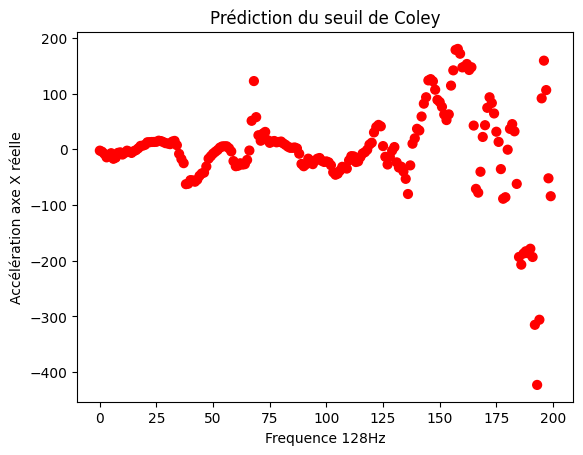

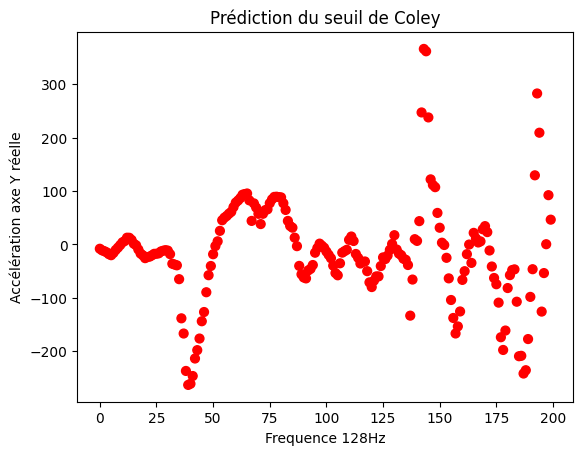

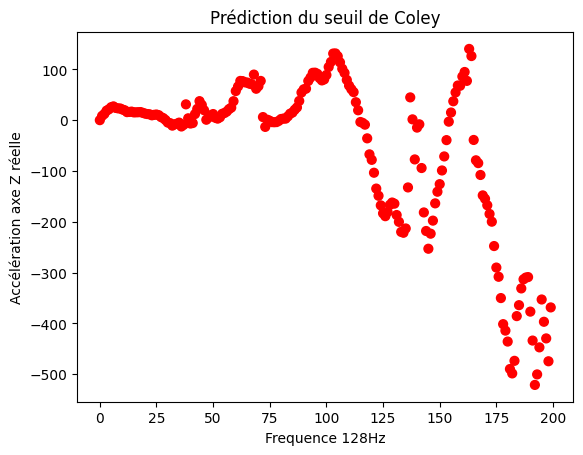

In [60]:
# Crée un mapping de couleur pour chaque label
label_to_color = {0: 'blue', 1: 'red', None : 'grey'}
colors = [label_to_color[y] for y in movement_prediction[0:200]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_gyro_dom_128_Hz[000:200])), X_gyro_dom_128_Hz[0:200], c=colors, s=40)
plt.title("Prédiction du seuil de Coley")
plt.xlabel("Frequence 128Hz")
plt.ylabel("Accélération axe X réelle")
plt.show()
# Crée un mapping de couleur pour chaque label
label_to_color = {0: 'blue', 1: 'red', None : 'grey'}
colors = [label_to_color[y] for y in movement_prediction[000:200]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(Y_gyro_dom_128_Hz[000:200])), Y_gyro_dom_128_Hz[00:200], c=colors, s=40)
plt.title("Prédiction du seuil de Coley")
plt.xlabel("Frequence 128Hz")
plt.ylabel("Accélération axe Y réelle")
plt.show()
# Crée un mapping de couleur pour chaque label
label_to_color = {0: 'blue', 1: 'red', None : 'grey'}
colors = [label_to_color[y] for y in movement_prediction[000:200]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(Z_gyro_dom_128_Hz[000:200])), Z_gyro_dom_128_Hz[000:200], c=colors, s=40)
plt.title("Prédiction du seuil de Coley")
plt.xlabel("Frequence 128Hz")
plt.ylabel("Accélération axe Z réelle")
plt.show()


4. Rééchantillonage à 1Hz

In [61]:
def downsample_to_1Hz(binary_array, sampling_rate = 128):
    n_seconds = len(binary_array) // sampling_rate
    # Troncature pour être multiple de 128
    binary_array = binary_array[:n_seconds * sampling_rate]  
    # Vote à la majorité : si au moins 64 échantillons sont actifs, on considère la seconde comme mouvement
    reshaped = binary_array.reshape(n_seconds, sampling_rate)
    return (reshaped.sum(axis=1) >= (sampling_rate // 2)).astype(int)

predicted_1Hz = downsample_to_1Hz(movement_prediction)
predicted_1Hz_non_dom = downsample_to_1Hz(movement_prediction_non_dom)

# Coupure des annotations prédictive à la longueur des données d'accélération (les données de mouvement ne sont pas toutes annotées)
predicted_1Hz = predicted_1Hz[:len(list_dom_x)]
predicted_1Hz_non_dom = predicted_1Hz_non_dom[:len(list_dom_x)]



5. Nettoyage annotations

In [62]:
total_list_dom_sec = np.arange(1,len(Y_dom_all)+1)
total_list_non_dom_sec = np.arange(1,len(Y_non_dom_all)+1)
predicted_1Hz = np.array(predicted_1Hz)
predicted_1Hz_non_dom = np.array(predicted_1Hz_non_dom)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_dom = Y_dom_all != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_non_dom = Y_non_dom_all != None

predicted_1Hz = predicted_1Hz[mask_dom[0:len(predicted_1Hz)]]
predicted_1Hz_non_dom = predicted_1Hz_non_dom[mask_non_dom[0:len(predicted_1Hz_non_dom)]]
Y_dom_all = Y_dom_all[mask_dom]
Y_non_dom_all = Y_non_dom_all[mask_non_dom]
list_dom_sec =  total_list_dom_sec[mask_dom]
list_non_dom_sec = total_list_non_dom_sec[mask_non_dom]

print("len(Y_non_dom) après nettoyage :", len(Y_non_dom_all))

len(Y_non_dom) après nettoyage : 875


In [63]:
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)


# GA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_dom = Y_dom_ga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_non_dom = Y_non_dom_ga != None

Y_dom_ga = Y_dom_ga[mask_ga_dom]
Y_non_dom_ga = Y_non_dom_ga[mask_ga_non_dom]

#FAGA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_dom = Y_dom_faga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_non_dom = Y_non_dom_faga != None

Y_dom_faga = Y_dom_faga[mask_faga_dom]
Y_non_dom_faga = Y_non_dom_faga[mask_faga_non_dom]


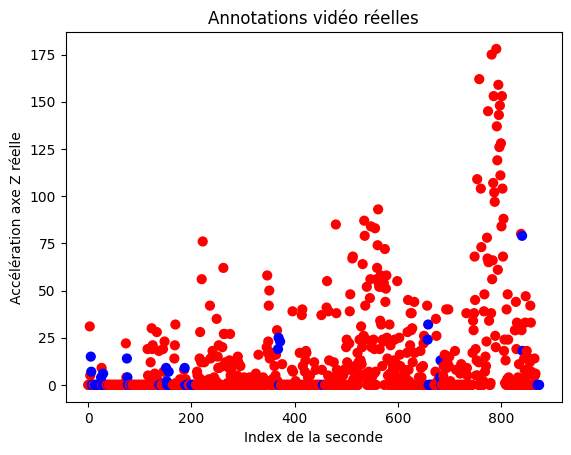

'# Crée un mapping de couleur pour chaque label\nlabel_to_color = {0: \'blue\', 1: \'red\', None : \'grey\'}\ncolors = [label_to_color[y] for y in predicted_1Hz_non_dom]\n# Affichage : index en abscisse, intensité en ordonnée\nplt.scatter(range(len(list_non_dom_x[mask_non_dom])), list_non_dom_z[mask_non_dom], c=colors, s=40)\nplt.title("Prédiction du seuil de Coley")\nplt.xlabel("Index de la seconde")\nplt.ylabel("Accélération axe Z réelle")\nplt.show()'

In [64]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_non_dom_all]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(list_non_dom_x[mask_non_dom])), list_non_dom_z[mask_non_dom], c=colors, s=40)
plt.title("Annotations vidéo réelles")
plt.xlabel("Index de la seconde")
plt.ylabel("Accélération axe Z réelle")
plt.show()


"""# Crée un mapping de couleur pour chaque label
label_to_color = {0: 'blue', 1: 'red', None : 'grey'}
colors = [label_to_color[y] for y in predicted_1Hz_non_dom]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(list_non_dom_x[mask_non_dom])), list_non_dom_z[mask_non_dom], c=colors, s=40)
plt.title("Prédiction du seuil de Coley")
plt.xlabel("Index de la seconde")
plt.ylabel("Accélération axe Z réelle")
plt.show()"""


6. Accuracy et F1 scores

In [65]:
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)

# -------------------------------------------- Transformation des labels --------------------------------------------
# Transformation des labels GA
Y_dom_ga_int = np.where(Y_dom_ga == 'mouvement' , 1, 0)
Y_non_dom_ga_int = np.where(Y_non_dom_ga == "mouvement", 1, 0)

# Transformation des labels GA
Y_dom_faga_int = np.where(Y_dom_faga == "mouvement" , 1, 0)
Y_non_dom_faga_int = np.where(Y_non_dom_faga == "mouvement", 1, 0)

# Transformation des labels all
Y_dom_all_int = np.where(Y_dom_all == "mouvement" , 1, 0)
Y_non_dom_all_int = np.where(Y_non_dom_all == "mouvement", 1, 0)

# ---------------------------- lst_Y_pred sont des numpy int mais Y_dom_all sont des int : il faut convertir les numpy int pour qu'ils correspondent aux int ------------------------------
# ga
Y_dom_ga_int = np.array(Y_dom_ga_int, dtype=np.int32)
Y_non_dom_ga_int = np.array(Y_non_dom_ga_int, dtype=np.int32)

# all
Y_dom_faga_int = np.array(Y_dom_faga_int, dtype=np.int32)
Y_non_dom_faga_int = np.array(Y_non_dom_faga_int, dtype=np.int32)

# all
Y_dom_all_int = np.array(Y_dom_all_int, dtype=np.int32)
Y_non_dom_all_int = np.array(Y_non_dom_all_int, dtype=np.int32)

# -------------------------------------------- Accuracy ---------------------------------------------

# ga
accuracy_dom_ga_0 = accuracy_score(Y_dom_ga_int[:len(predicted_1Hz)],predicted_1Hz)
print("Accuracy dom ga : ", accuracy_dom_ga_0)
accuracy_non_dom_ga_0 = accuracy_score(Y_non_dom_ga_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom)
print("Accuracy non dom ga : ", accuracy_non_dom_ga_0)

# faga
accuracy_dom_faga_0 = accuracy_score(Y_dom_faga_int[:len(predicted_1Hz)],predicted_1Hz)
print("Accuracy dom faga : ", accuracy_dom_faga_0)
accuracy_non_dom_faga_0 = accuracy_score(Y_non_dom_faga_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom)
print("Accuracy non dom faga : ", accuracy_non_dom_faga_0)

# all
accuracy_dom_all_0 = accuracy_score(Y_dom_all_int[:len(predicted_1Hz)],predicted_1Hz)
print("Accuracy dom all : ", accuracy_dom_all_0)
accuracy_non_dom_all_0 = accuracy_score(Y_non_dom_all_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom)
print("Accuracy non dom all : ", accuracy_non_dom_all_0)


# -------------------------------------------- F1 scores  ---------------------------------------------
# ga 
f1_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(predicted_1Hz)],predicted_1Hz, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_ga_0 = f1_score(Y_dom_ga_int[:len(predicted_1Hz)],predicted_1Hz, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_ga_0 = f1_score(Y_non_dom_ga_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom, labels = [0,1], pos_label = 0 , average = "binary")

# faga
f1_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(predicted_1Hz)],predicted_1Hz, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_faga_0 = f1_score(Y_dom_faga_int[:len(predicted_1Hz)],predicted_1Hz, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_faga_0 = f1_score(Y_non_dom_faga_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom, labels = [0,1], pos_label = 0 , average = "binary")

# all
f1_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(predicted_1Hz)],predicted_1Hz, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_dom_all_0 = f1_score(Y_dom_all_int[:len(predicted_1Hz)],predicted_1Hz, labels = [0,1], pos_label = 0 , average = "binary")
f1_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom, labels = [0,1], pos_label = 1 , average = "binary")
f1_non_mvt_non_dom_all_0 = f1_score(Y_non_dom_all_int[:len(predicted_1Hz_non_dom)],predicted_1Hz_non_dom, labels = [0,1], pos_label = 0 , average = "binary")


Accuracy dom ga :  0.7529880478087649
Accuracy non dom ga :  0.5491803278688525
Accuracy dom faga :  0.751660026560425
Accuracy non dom faga :  0.6010928961748634
Accuracy dom all :  0.751660026560425
Accuracy non dom all :  0.7978142076502732


7. Enregistrement dans les fichiers Excel

In [66]:
# Select file
if os.path.exists(file_path_dom):
    my_wb = openpyxl.load_workbook(file_path_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "Coley", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_dom_sec[idx_sec]

# 2e colonne = résultats fenetre de puissance
for idx_pred in range(len(predicted_1Hz)):
    my_cell = my_sheet.cell(row = idx_pred + 2, column = 2)
    my_cell.value = predicted_1Hz[idx_pred]

# 3e colonne = Observation GA
for idx_obs_ga in range(len(Y_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 3)
    if Y_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 4e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 4)
    if Y_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = "ERREUR"

# 5e colonne = Observation All
for idx_obs_all in range(len(Y_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 5)
    if Y_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = "ERREUR"


# Autres colonnes : accuracy et F1 scores modèle 1
my_cell_title = my_sheet.cell(row = 5, column = 11)
my_cell_title.value = "Coley"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 11)
my_cell_title_acc_fa.value = "Accuracy ga"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 12)
my_cell_title_acc_gafa.value = "Accuracy faga"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 13)
my_cell_title_acc_all.value = "Accuracy all"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 11)
my_cell_acc_ga.value = accuracy_dom_ga_0
my_cell_acc_faga = my_sheet.cell(row = 7, column = 12)
my_cell_acc_faga.value = accuracy_dom_faga_0
my_cell_acc_all = my_sheet.cell(row = 7, column = 13)
my_cell_acc_all.value = accuracy_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 11)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 11)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row =9, column = 12)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 13)
my_cell_title_F1_mvt_all.value = "F1 mvt all"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 11)
my_cell_F1_mvt_ga.value = f1_mvt_dom_ga_0
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 12)
my_cell_F1_mvt_faga.value = f1_mvt_dom_faga_0
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 13)
my_cell_F1_mvt_all.value = f1_mvt_dom_all_0

my_cell_title_F1_non_mvt = my_sheet.cell(row = 11, column = 11)
my_cell_title_F1_non_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 11)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga "
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 12)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga "
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 13)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all "

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 11)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_dom_ga_0
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 12)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_dom_faga_0
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 13)
my_cell_F1_non_mvt_all.value = f1_non_mvt_dom_all_0

my_cell_time = my_sheet.cell(row = 7, column = 9)
my_cell_time.value = "Temps annoté "
my_cell_time_value = my_sheet.cell(row = 8, column = 9)
my_cell_time_value.value = len(Y_dom_all)


my_wb.save(file_path_dom)

File exists, loading existing data.
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne


In [67]:
# Select file
if os.path.exists(file_path_non_dom):
    my_wb = openpyxl.load_workbook(file_path_non_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "Coley",  "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_non_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_non_dom_sec[idx_sec]

# 2e colonne = résultats fenetre de puissance
for idx_pred in range(len(predicted_1Hz_non_dom)):
    my_cell = my_sheet.cell(row = idx_pred + 2, column = 2)
    my_cell.value = predicted_1Hz_non_dom[idx_pred]

# 3e colonne = Observation GA
for idx_obs_ga in range(len(Y_non_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 3)
    if Y_non_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 4e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_non_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 4)
    if Y_non_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = "ERREUR"

# 5e colonne = Observation All
for idx_obs_all in range(len(Y_non_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 5)
    if Y_non_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = "ERREUR"

# Autres colonnes : accuracy et F1 scores modèle 1
my_cell_title = my_sheet.cell(row = 5, column = 11)
my_cell_title.value = "Coley"
my_cell_title_acc_fa = my_sheet.cell(row = 6, column = 11)
my_cell_title_acc_fa.value = "Accuracy ga"
my_cell_title_acc_gafa = my_sheet.cell(row = 6, column = 12)
my_cell_title_acc_gafa.value = "Accuracy faga"
my_cell_title_acc_all = my_sheet.cell(row = 6, column = 13)
my_cell_title_acc_all.value = "Accuracy all"

my_cell_acc_ga = my_sheet.cell(row = 7, column = 11)
my_cell_acc_ga.value = accuracy_non_dom_ga_0
my_cell_acc_faga = my_sheet.cell(row = 7, column = 12)
my_cell_acc_faga.value = accuracy_non_dom_faga_0
my_cell_acc_all = my_sheet.cell(row = 7, column = 13)
my_cell_acc_all.value = accuracy_non_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 8, column = 11)
my_cell_title_F1_mvt.value = "F1 mvt "
my_cell_title_F1_mvt_fa = my_sheet.cell(row = 9, column = 11)
my_cell_title_F1_mvt_fa.value = "F1 mvt ga"
my_cell_title_F1_mvt_gafa = my_sheet.cell(row = 9, column = 12)
my_cell_title_F1_mvt_gafa.value = "F1 mvt faga"
my_cell_title_F1_mvt_all = my_sheet.cell(row = 9, column = 13)
my_cell_title_F1_mvt_all.value = "F1 mvt all"

my_cell_F1_mvt_ga = my_sheet.cell(row = 10, column = 11)
my_cell_F1_mvt_ga.value = f1_mvt_non_dom_ga_0
my_cell_F1_mvt_faga = my_sheet.cell(row = 10, column = 12)
my_cell_F1_mvt_faga.value = f1_mvt_non_dom_faga_0
my_cell_F1_mvt_all = my_sheet.cell(row = 10, column = 13)
my_cell_F1_mvt_all.value = f1_mvt_non_dom_all_0

my_cell_title_F1_mvt = my_sheet.cell(row = 11, column = 11)
my_cell_title_F1_mvt.value = "F1 non mvt "
my_cell_title_F1_non_mvt_fa = my_sheet.cell(row = 12, column = 11)
my_cell_title_F1_non_mvt_fa.value = "F1 non mvt ga"
my_cell_title_F1_non_mvt_gafa = my_sheet.cell(row = 12, column = 12)
my_cell_title_F1_non_mvt_gafa.value = "F1 non mvt faga"
my_cell_title_F1_non_mvt_all = my_sheet.cell(row = 12, column = 13)
my_cell_title_F1_non_mvt_all.value = "F1 non mvt all"

my_cell_F1_non_mvt_ga = my_sheet.cell(row = 13, column = 11)
my_cell_F1_non_mvt_ga.value = f1_non_mvt_non_dom_ga_0
my_cell_F1_non_mvt_faga = my_sheet.cell(row = 13, column = 12)
my_cell_F1_non_mvt_faga.value = f1_non_mvt_non_dom_faga_0
my_cell_F1_non_mvt_all = my_sheet.cell(row = 13, column = 13)
my_cell_F1_non_mvt_all.value = f1_non_mvt_non_dom_all_0


my_cell_time = my_sheet.cell(row = 7, column = 9)
my_cell_time.value = "Temps annoté "
my_cell_time_value = my_sheet.cell(row = 8, column = 9)
my_cell_time_value.value = len(Y_dom_all)

my_wb.save(file_path_non_dom)

File exists, loading existing data.
créer une colonne
créer une colonne
créer une colonne
créer une colonne
créer une colonne
